# Customer Churn Analysis

## Business Problem

The e-commerce company experiences customer churn, which negatively impacts revenue and customer lifetime value.

The objective of this project is to identify factors associated with customer churn and provide recommendations to improve customer retention.

## Project Goals

- Analyze customer churn rate
- Identify churn patterns
- Explore customer behavior
- Provide business recommendations

## 1. Data Loading

In this section, we load the dataset and perform an initial review of its structure.

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/ecommerce_customer_churn_dataset.csv")

In [4]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


## 2. Dataset Overview

In this section, we examine the dataset size, column names, data types, and missing values.

In [5]:
df.shape

(50000, 25)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null  float64
 1

In [9]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='str')

## 3. Data Quality Assessment

In this section, we check for missing values and duplicate records to evaluate data quality before analysis.

In [10]:
df.isnull().sum()

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

In [12]:
(df.isnull().sum() / len(df) * 100).round(2)

Age                               4.99
Gender                            0.00
Country                           0.00
City                              0.00
Membership_Years                  0.00
Login_Frequency                   0.00
Session_Duration_Avg              6.80
Pages_Per_Session                 6.00
Cart_Abandonment_Rate             0.00
Wishlist_Items                    8.00
Total_Purchases                   0.00
Average_Order_Value               0.00
Days_Since_Last_Purchase          6.00
Discount_Usage_Rate               7.00
Returns_Rate                      8.98
Email_Open_Rate                   5.06
Customer_Service_Calls            0.34
Product_Reviews_Written           7.00
Social_Media_Engagement_Score    12.00
Mobile_App_Usage                 10.00
Payment_Method_Diversity          5.00
Lifetime_Value                    0.00
Credit_Balance                   11.00
Churned                           0.00
Signup_Quarter                    0.00
dtype: float64

In [13]:
df.duplicated().sum()

np.int64(0)

### Data Quality Findings

- The dataset contains 50,000 customer records and 25 variables.
- No duplicate records were identified.
- Several variables contain missing values, with the highest percentages observed in:
  - Social_Media_Engagement_Score (12%)
  - Credit_Balance (11%)
  - Mobile_App_Usage (10%)
- Missing values will be addressed later depending on analytical requirements.

## 4. Customer Churn Overview

In this section, we analyze the overall customer churn rate.

In [14]:
df['Churned'].value_counts()

Churned
0    35550
1    14450
Name: count, dtype: int64

In [15]:
(df['Churned'].mean() * 100).round(2)

np.float64(28.9)

In [16]:
churn_rate = round(df['Churned'].mean() * 100, 2)

print(f"Customer Churn Rate: {churn_rate}%")

Customer Churn Rate: 28.9%


### Churn Rate Findings

The overall customer churn rate is 28.9%.

Out of 50,000 customers, 14,450 have churned while 35,550 remained active.

This indicates that nearly one in three customers leaves the platform, highlighting the importance of customer retention initiatives.

### Churn Distribution

In [17]:
import matplotlib.pyplot as plt

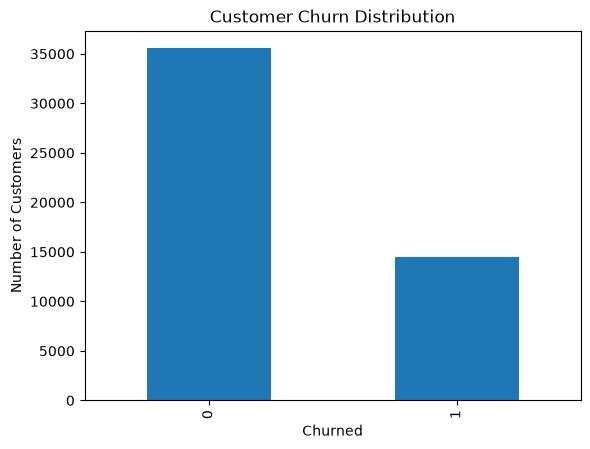

In [18]:
df['Churned'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churned')
plt.ylabel('Number of Customers')

plt.show()

## 5. Churn Analysis by Age

In this section, we compare customer age between churned and active customers.

In [19]:
df.groupby('Churned')['Age'].mean()

Churned
0    38.582557
1    35.902598
Name: Age, dtype: float64

### Age Analysis Findings

The average age of active customers is 38.58 years, while churned customers have an average age of 35.90 years.

Churned customers are approximately 2.7 years younger on average.

There is a slight age difference between churned and active customers.

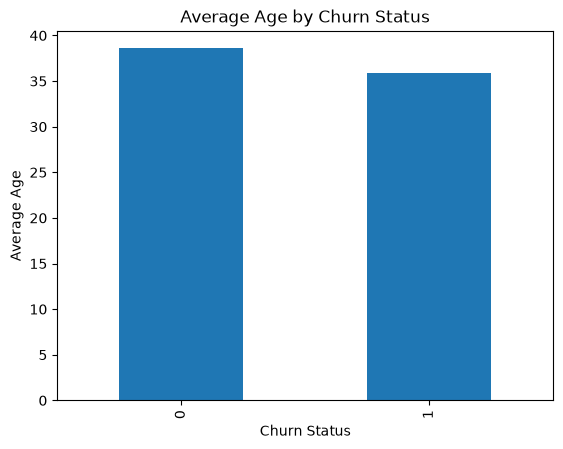

In [20]:
df.groupby('Churned')['Age'].mean().plot(kind='bar')

plt.title('Average Age by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Average Age')

plt.show()

## 6. Churn Analysis by Membership Duration

In this section, we compare membership duration between active and churned customers.

In [21]:
df.groupby('Churned')['Membership_Years'].mean()

Churned
0    2.984828
1    2.981996
Name: Membership_Years, dtype: float64

### Membership Duration Findings

The average membership duration is nearly identical for both active and churned customers.

This suggests that membership duration is not a significant factor associated with customer churn in this dataset.

## 7. Churn Analysis by Login Frequency

In this section, we compare login frequency between active and churned customers.

In [22]:
df.groupby('Churned')['Login_Frequency'].mean()

Churned
0    12.642391
1     9.120830
Name: Login_Frequency, dtype: float64

### Login Frequency Findings

Active customers log in an average of 12.64 times, while churned customers log in only 9.12 times.

Churned customers demonstrate significantly lower engagement, logging in approximately 28% less frequently than active customers.

This suggests that login frequency may be an important indicator of customer retention.

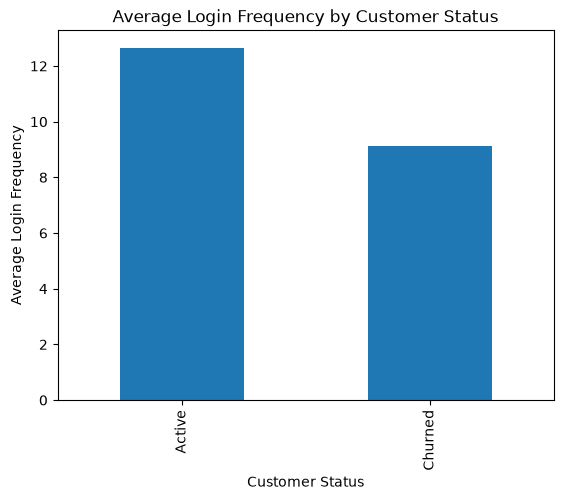

In [23]:
login_avg = df.groupby('Churned')['Login_Frequency'].mean()

login_avg.index = ['Active', 'Churned']

login_avg.plot(kind='bar')

plt.title('Average Login Frequency by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Average Login Frequency')

plt.show()

## 8. Churn Analysis by Purchase Activity

In this section, we compare the number of days since the last purchase between active and churned customers.

In [24]:
df.groupby('Churned')['Days_Since_Last_Purchase'].mean()

Churned
0    26.892026
1    36.942135
Name: Days_Since_Last_Purchase, dtype: float64

### Purchase Activity Findings

Churned customers have not made a purchase for an average of 36.94 days, compared to 26.89 days for active customers.

This represents a difference of more than 10 days.

The results suggest that purchase inactivity is strongly associated with customer churn and may serve as an early warning indicator for retention efforts.

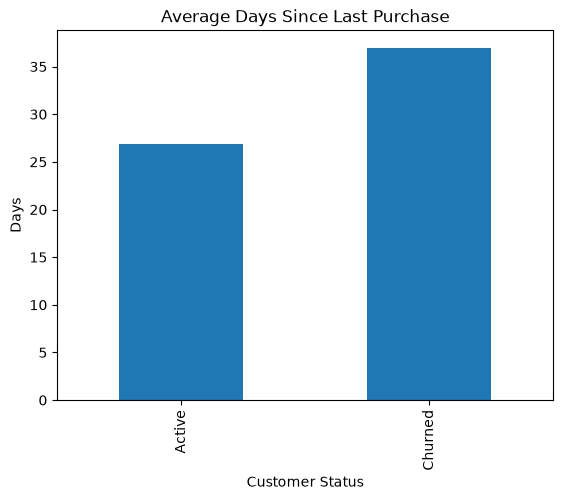

In [25]:
purchase_gap = df.groupby('Churned')['Days_Since_Last_Purchase'].mean()

purchase_gap.index = ['Active', 'Churned']

purchase_gap.plot(kind='bar')

plt.title('Average Days Since Last Purchase')
plt.xlabel('Customer Status')
plt.ylabel('Days')

plt.show()

## 9. Churn Analysis by Total Purchases

In this section, we compare the total number of purchases between active and churned customers.

In [26]:
df.groupby('Churned')['Total_Purchases'].mean()

Churned
0    13.827522
1    11.350201
Name: Total_Purchases, dtype: float64

### Total Purchases Findings

Active customers made an average of 13.83 purchases, while churned customers made 11.35 purchases.

This represents approximately 18% fewer purchases among churned customers.

The findings suggest that customers with lower purchase activity are more likely to leave the platform.

## Interim Business Insights

The analysis identified several factors associated with customer churn.

Key observations include:

- Churned customers log in less frequently than active customers.
- Churned customers remain inactive for longer periods after their last purchase.
- Churned customers make fewer purchases overall.
- Membership duration shows little to no relationship with churn.
- Age appears to have only a minor association with churn.

These findings suggest that customer engagement and purchase activity are stronger indicators of churn than demographic characteristics.

## 10. Correlation Analysis

In this section, we examine relationships between numerical variables and identify factors associated with customer churn.

In [27]:
import seaborn as sns

In [30]:
corr_matrix['Churned'].sort_values()

Pages_Per_Session               -0.231799
Session_Duration_Avg            -0.228010
Mobile_App_Usage                -0.222876
Email_Open_Rate                 -0.222213
Login_Frequency                 -0.204379
Wishlist_Items                  -0.197708
Social_Media_Engagement_Score   -0.191792
Product_Reviews_Written         -0.181225
Total_Purchases                 -0.160029
Credit_Balance                  -0.156921
Age                             -0.102849
Discount_Usage_Rate             -0.077121
Lifetime_Value                  -0.010684
Membership_Years                -0.000623
Payment_Method_Diversity         0.004524
Average_Order_Value              0.042288
Returns_Rate                     0.054189
Days_Since_Last_Purchase         0.153360
Cart_Abandonment_Rate            0.277963
Customer_Service_Calls           0.291103
Churned                          1.000000
Name: Churned, dtype: float64

## 11. Top Factors Associated with Churn

In [31]:
churn_corr = corr_matrix['Churned'].drop('Churned')

churn_corr.sort_values()

Pages_Per_Session               -0.231799
Session_Duration_Avg            -0.228010
Mobile_App_Usage                -0.222876
Email_Open_Rate                 -0.222213
Login_Frequency                 -0.204379
Wishlist_Items                  -0.197708
Social_Media_Engagement_Score   -0.191792
Product_Reviews_Written         -0.181225
Total_Purchases                 -0.160029
Credit_Balance                  -0.156921
Age                             -0.102849
Discount_Usage_Rate             -0.077121
Lifetime_Value                  -0.010684
Membership_Years                -0.000623
Payment_Method_Diversity         0.004524
Average_Order_Value              0.042288
Returns_Rate                     0.054189
Days_Since_Last_Purchase         0.153360
Cart_Abandonment_Rate            0.277963
Customer_Service_Calls           0.291103
Name: Churned, dtype: float64

### Top Factors Associated with Customer Churn

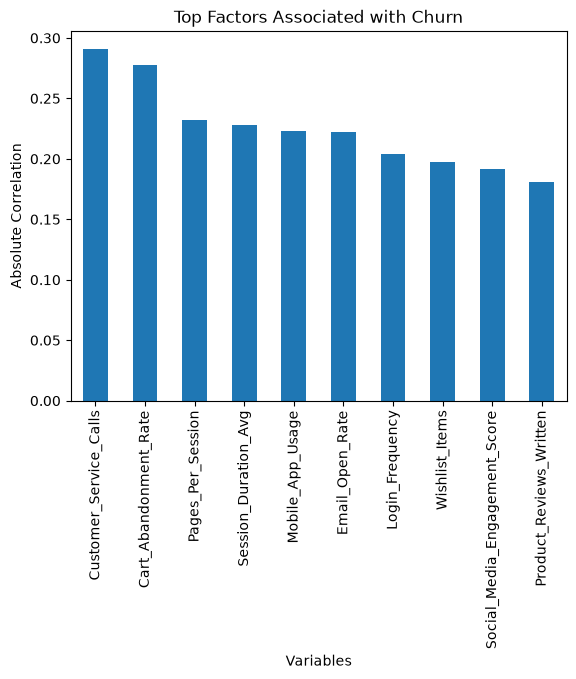

In [32]:
top_corr = churn_corr.abs().sort_values(ascending=False).head(10)

top_corr.plot(kind='bar')

plt.title('Top Factors Associated with Churn')
plt.xlabel('Variables')
plt.ylabel('Absolute Correlation')

plt.show()

## Final Business Insights

### Key Findings

1. The overall customer churn rate is 28.9%, indicating that nearly one-third of customers leave the platform.

2. Customer engagement is strongly associated with retention. Active customers log in more frequently, spend more time per session, open more emails, and use the mobile app more often.

3. Customers with higher cart abandonment rates are more likely to churn, suggesting friction in the purchase process.

4. Churned customers remain inactive for longer periods after their last purchase, making purchase inactivity an important early warning indicator.

5. A higher number of customer service calls is associated with increased churn, potentially indicating unresolved issues or customer dissatisfaction.

## Business Recommendations

### Recommended Actions

1. Identify customers who have not made a purchase within the last 30 days and target them with retention campaigns.

2. Monitor customers with high cart abandonment rates and offer personalized incentives to complete purchases.

3. Improve customer support processes and investigate the reasons behind frequent customer service contacts.

4. Increase customer engagement through email campaigns, loyalty programs, and mobile app promotions.

5. Develop an early warning system using engagement and purchase activity metrics to proactively identify at-risk customers.

## 12. Export Dataset for Power BI


In [33]:
df.to_csv('../data/customer_churn_clean.csv', index=False)